# Logistic Regression

In statistics, a logistic model (or logit model) is a statistical model that models the log-odds of an event as a linear combination of one or more independent variables.


---



Logistic regression is a supervised machine learning algorithm widely used for binary classification tasks, such as identifying whether an email is spam or not and diagnosing diseases by assessing the presence or absence of specific conditions based on patient test results.

Exam_pass_logistic_curve.svg

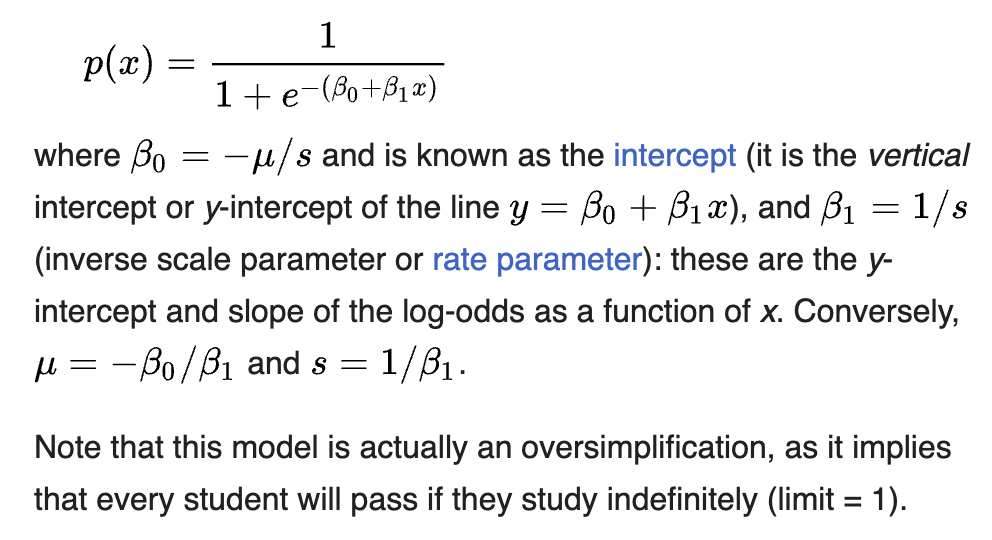

# Uses of Logistic Regression:
Logistic regression is used in various fields, including machine learning, most medical fields, and social sciences. For example, the Trauma and Injury Severity Score (TRISS), which is widely used to predict mortality in injured patients, was originally developed by Boyd et al. using logistic regression.
<br/> Many other medical scales used to assess severity of a patient have been developed using logistic regression. Logistic regression may be used to predict the risk of developing a given disease (e.g. diabetes; coronary heart disease), based on observed characteristics of the patient (age, sex, body mass index, results of various blood tests, etc.). Another example might be to predict whether a Nepalese voter will vote Nepali Congress or Communist Party of Nepal or for any other party, based on age, income, sex, race, state of residence, votes in previous elections, etc

# Step 1 : Load Dataset

In [1]:
import pandas as pd
from google.colab import files
files.upload()
df = pd.read_csv('health_dataset.csv')

Saving health_dataset.csv to health_dataset.csv


In [2]:
df.head()

,age,bmi,smoking,physical_activity,disease
0,58,32.8,0,1,1
1,48,24.4,0,1,0
2,34,21.4,0,0,0
3,62,21.7,0,1,0
4,27,23.1,1,0,1


# Step 2: Inspect the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                200 non-null    int64  
 1   bmi                200 non-null    float64
 2   smoking            200 non-null    int64  
 3   physical_activity  200 non-null    int64  
 4   disease            200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [4]:
df.describe()

,age,bmi,smoking,physical_activity,disease
count,200.000000,200.00000,200.000000,200.000000,200.000000
mean,44.635000,25.06650,0.305000,0.540000,0.480000
std,14.656598,4.12915,0.461563,0.499648,0.500854
min,20.000000,17.00000,0.000000,0.000000,0.000000
25%,32.000000,22.20000,0.000000,0.000000,0.000000
50%,45.000000,25.00000,0.000000,1.000000,0.000000
75%,58.000000,27.90000,1.000000,1.000000,1.000000
max,70.000000,37.70000,1.000000,1.000000,1.000000


In [5]:
df.isna().sum()

,0
age,0
bmi,0
smoking,0
physical_activity,0
disease,0


# Step 3: Define X and y

*Remember:*

X = predictors/input <br/>
y = outcome/output

In [6]:
X = df[["age", "bmi", "smoking"]]
y = df["disease"]

# Step 4: Split into training and testing data

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape

((160, 3), (40, 3))

# Step 5: Train the model

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

# Step 6 : Make predictions ⭐

In [13]:
# A. Predict class
y_pred = model.predict(X_test)

In [12]:
y_pred

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0])

In [14]:
# B. Predict probability
y_prob = model.predict_proba(X_test)[:, 1]

In [15]:
y_prob

array([0.65244184, 0.13406472, 0.49993722, 0.41925498, 0.26354863,
       0.11821544, 0.54501345, 0.55973211, 0.72392726, 0.60428556,
       0.07210355, 0.80333094, 0.43511151, 0.24556427, 0.3773187 ,
       0.87385401, 0.34013417, 0.78357699, 0.18681754, 0.1067586 ,
       0.72329991, 0.31600617, 0.26650409, 0.25142875, 0.87192425,
       0.53385169, 0.60639231, 0.16141358, 0.48201207, 0.84035207,
       0.18657938, 0.4682184 , 0.74180493, 0.68400826, 0.24178079,
       0.08004161, 0.48246462, 0.51246509, 0.81491614, 0.22636899])

# Step 7 : Evaluate the model ⭐⭐⭐

For classification, don’t use MAE/RMSE/R² as your primary evaluation metrics.

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8
[[17  2]
 [ 6 15]]
              precision    recall  f1-score   support

           0       0.74      0.89      0.81        19
           1       0.88      0.71      0.79        21

    accuracy                           0.80        40
   macro avg       0.81      0.80      0.80        40
weighted avg       0.81      0.80      0.80        40



# Step 8: ROC-AUC ⭐

*Notice** that we use y_prob rather than:because ROC-AUC evaluates the model’s ability to rank positive cases by predicted probability.*

In [28]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.8897243107769424


# Step 9:Look at coefficients

In [29]:
pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

,Variable,Coefficient
0,age,0.065214
1,bmi,0.085744
2,smoking,1.113423


In [30]:
model.intercept_[0]

np.float64(-5.563823490303876)

# The End

# Overall Code

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

df = pd.read_csv("data.csv")

X = df[["age", "bmi", "smoking"]]
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))